In [1]:
# ============================================================
# Modeling Part 2 - Baseline and Quintile Tests
# ============================================================
#
# Goal:
# 1. Load the clean simple earnings straddle dataset from Modeling Part 1
# 2. Understand the baseline average edge
# 3. Sort earnings events into quintiles using simple signals
# 4. Check whether those signals predict future straddle edge
# 5. Save quintile test results for later use
#
# Main target:
# simple_straddle_edge_open = realized_move_open_to_prevclose - implied_move_simple
#
# Positive edge:
#     stock moved more than options implied
#     straddle was cheap
#
# Negative edge:
#     stock moved less than options implied
#     straddle was expensive

import os
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

con = duckdb.connect()

PROCESSED_DIR = r"data\processed"

# Main dataset from Modeling Part 1
loose_file = os.path.join(PROCESSED_DIR, "earnings_model_simple_clean_loose.parquet")
strict_file = os.path.join(PROCESSED_DIR, "earnings_model_simple_clean_strict.parquet")

# Output files
quintile_results_file = os.path.join(PROCESSED_DIR, "modeling_part2_quintile_results.parquet")
yearly_quintile_results_file = os.path.join(PROCESSED_DIR, "modeling_part2_yearly_quintile_results.parquet")

print("Loose input file:")
print(loose_file)

print("\nStrict input file:")
print(strict_file)

Loose input file:
data\processed\earnings_model_simple_clean_loose.parquet

Strict input file:
data\processed\earnings_model_simple_clean_strict.parquet


In [2]:
# Helper function to print SQL query output neatly

def show(title, query, n=30):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)
    
    df = con.execute(query).df()
    
    if len(df) > n:
        print(df.head(n).to_string(index=False))
        print(f"\n[showing first {n} rows out of {len(df)}]")
    else:
        print(df.to_string(index=False))
    
    return df


# Helper function for formatting percentages in pandas tables later

def pct(x):
    if pd.isna(x):
        return ""
    return f"{100*x:.2f}%"

In [3]:
# Check that the datasets from Modeling Part 1 exist

for file in [loose_file, strict_file]:
    if not os.path.exists(file):
        raise FileNotFoundError(
            f"Could not find {file}. "
            "Run Modeling Part 1 first."
        )

print("Both loose and strict files found.")

Both loose and strict files found.


In [4]:
# Load both datasets.
#
# Loose:
#     larger dataset, better for first exploration
#
# Strict:
#     cleaner liquidity filters, useful as robustness check

con.execute(f"""
CREATE OR REPLACE TEMP TABLE loose AS
SELECT *
FROM read_parquet('{loose_file}')
""")

con.execute(f"""
CREATE OR REPLACE TEMP TABLE strict AS
SELECT *
FROM read_parquet('{strict_file}')
""")

show(
    "Row counts",
    """
    SELECT 'loose' AS dataset, COUNT(*) AS n_rows, COUNT(DISTINCT tic) AS n_tickers FROM loose
    UNION ALL
    SELECT 'strict' AS dataset, COUNT(*) AS n_rows, COUNT(DISTINCT tic) AS n_tickers FROM strict
    """
)


Row counts
dataset  n_rows  n_tickers
  loose    9022        474
 strict    7412        457


,dataset,n_rows,n_tickers
0,loose,9022,474
1,strict,7412,457


In [5]:
# Check the main target variable.
#
# simple_straddle_edge_open = realized move - implied move
#
# If average edge is negative:
#     average straddle was expensive
#
# If average edge is positive:
#     average straddle was cheap

show(
    "Baseline edge summary",
    """
    SELECT
        'loose' AS dataset,
        COUNT(*) AS n_events,
        AVG(implied_move_simple) AS avg_implied_move,
        AVG(realized_move_open_to_prevclose) AS avg_realized_move,
        AVG(simple_straddle_edge_open) AS avg_edge,
        APPROX_QUANTILE(simple_straddle_edge_open, 0.05) AS edge_p05,
        APPROX_QUANTILE(simple_straddle_edge_open, 0.50) AS edge_median,
        APPROX_QUANTILE(simple_straddle_edge_open, 0.95) AS edge_p95
    FROM loose

    UNION ALL

    SELECT
        'strict' AS dataset,
        COUNT(*) AS n_events,
        AVG(implied_move_simple) AS avg_implied_move,
        AVG(realized_move_open_to_prevclose) AS avg_realized_move,
        AVG(simple_straddle_edge_open) AS avg_edge,
        APPROX_QUANTILE(simple_straddle_edge_open, 0.05) AS edge_p05,
        APPROX_QUANTILE(simple_straddle_edge_open, 0.50) AS edge_median,
        APPROX_QUANTILE(simple_straddle_edge_open, 0.95) AS edge_p95
    FROM strict
    """
)


Baseline edge summary
dataset  n_events  avg_implied_move  avg_realized_move  avg_edge  edge_p05  edge_median  edge_p95
  loose      9022          0.057131           0.042723 -0.014408 -0.066355    -0.019029  0.051366
 strict      7412          0.057282           0.043692 -0.013590 -0.066839    -0.017661  0.052690


,dataset,n_events,avg_implied_move,avg_realized_move,avg_edge,edge_p05,edge_median,edge_p95
0,loose,9022,0.057131,0.042723,-0.014408,-0.066355,-0.019029,0.051366
1,strict,7412,0.057282,0.043692,-0.013590,-0.066839,-0.017661,0.052690


In [6]:
# Create a working table with extra simple signals.
#
# These signals are all known before earnings, so they are allowed.
#
# total_spread_pct:
#     average of call spread percentage and put spread percentage
#
# total_open_interest:
#     call open interest + put open interest
#
# total_volume:
#     call volume + put volume
#
# log_total_open_interest:
#     log version of open interest
#     log helps reduce the effect of extremely large values
#
# log_total_volume:
#     log version of volume

con.execute("""
CREATE OR REPLACE TEMP TABLE loose_work AS
SELECT
    *,
    
    (after_call_spread_pct + after_put_spread_pct) / 2.0 AS total_spread_pct,
    
    COALESCE(after_call_oi, 0) + COALESCE(after_put_oi, 0) AS total_open_interest,
    
    COALESCE(after_call_vol, 0) + COALESCE(after_put_vol, 0) AS total_volume,
    
    LN(1 + COALESCE(after_call_oi, 0) + COALESCE(after_put_oi, 0)) AS log_total_open_interest,
    
    LN(1 + COALESCE(after_call_vol, 0) + COALESCE(after_put_vol, 0)) AS log_total_volume

FROM loose
""")

con.execute("""
CREATE OR REPLACE TEMP TABLE strict_work AS
SELECT
    *,
    
    (after_call_spread_pct + after_put_spread_pct) / 2.0 AS total_spread_pct,
    
    COALESCE(after_call_oi, 0) + COALESCE(after_put_oi, 0) AS total_open_interest,
    
    COALESCE(after_call_vol, 0) + COALESCE(after_put_vol, 0) AS total_volume,
    
    LN(1 + COALESCE(after_call_oi, 0) + COALESCE(after_put_oi, 0)) AS log_total_open_interest,
    
    LN(1 + COALESCE(after_call_vol, 0) + COALESCE(after_put_vol, 0)) AS log_total_volume

FROM strict
""")

show(
    "Sample working rows",
    """
    SELECT
        tic,
        rdq,
        implied_move_simple,
        realized_move_open_to_prevclose,
        simple_straddle_edge_open,
        total_spread_pct,
        total_open_interest,
        total_volume,
        log_total_open_interest,
        log_total_volume
    FROM loose_work
    ORDER BY rdq, tic
    LIMIT 20
    """
)


Sample working rows
 tic        rdq  implied_move_simple  realized_move_open_to_prevclose  simple_straddle_edge_open  total_spread_pct  total_open_interest  total_volume  log_total_open_interest  log_total_volume
NVDA 2018-02-08             0.082496                         0.041302                  -0.041193          0.029434                 4347          5135                 8.377471          8.544030
   A 2018-02-14             0.038118                         0.096576                   0.058458          0.128590                 1633            82                 7.398786          4.418841
AMAT 2018-02-14             0.057316                         0.052674                  -0.004642          0.035222                  795           736                 6.679599          6.602588
CSCO 2018-02-14             0.049600                         0.093015                   0.043415          0.025347                17855          5621                 9.790095          8.634443
NTAP 2018-02-1

,tic,rdq,implied_move_simple,realized_move_open_to_prevclose,simple_straddle_edge_open,total_spread_pct,total_open_interest,total_volume,log_total_open_interest,log_total_volume
0,NVDA,2018-02-08,0.082496,0.041302,-0.041193,0.029434,4347,5135,8.377471,8.544030
1,A,2018-02-14,0.038118,0.096576,0.058458,0.128590,1633,82,7.398786,4.418841
2,AMAT,2018-02-14,0.057316,0.052674,-0.004642,0.035222,795,736,6.679599,6.602588
3,CSCO,2018-02-14,0.049600,0.093015,0.043415,0.025347,17855,5621,9.790095,8.634443
4,NTAP,2018-02-14,0.077034,0.070991,-0.006044,0.037560,145,19,4.983607,2.995732
5,DE,2018-02-16,0.054253,0.013368,-0.040885,0.098527,763,133,6.638568,4.897840
6,HD,2018-02-20,0.036102,0.001284,-0.034818,0.059043,2837,2339,7.950855,7.757906
7,MDT,2018-02-20,0.041592,0.022566,-0.019025,0.020263,66,2458,4.204693,7.807510
8,WMT,2018-02-20,0.052491,0.092289,0.039798,0.043379,2505,3804,7.826443,8.244071
9,HPE,2018-02-22,0.060308,0.108308,0.048000,0.200709,507,135,6.230481,4.912655


In [7]:
# Check the candidate sorting signals.
#
# These are not models yet.
# They are simple variables we can use to rank earnings events.

show(
    "Signal summary: loose dataset",
    """
    SELECT
        COUNT(*) AS n_events,

        AVG(implied_move_simple) AS avg_implied_move,
        APPROX_QUANTILE(implied_move_simple, 0.50) AS median_implied_move,

        AVG(total_spread_pct) AS avg_total_spread_pct,
        APPROX_QUANTILE(total_spread_pct, 0.50) AS median_total_spread_pct,

        AVG(total_open_interest) AS avg_total_open_interest,
        APPROX_QUANTILE(total_open_interest, 0.50) AS median_total_open_interest,

        AVG(total_volume) AS avg_total_volume,
        APPROX_QUANTILE(total_volume, 0.50) AS median_total_volume,

        AVG(om_close) AS avg_stock_price,
        APPROX_QUANTILE(om_close, 0.50) AS median_stock_price
    FROM loose_work
    """
)


Signal summary: loose dataset
 n_events  avg_implied_move  median_implied_move  avg_total_spread_pct  median_total_spread_pct  avg_total_open_interest  median_total_open_interest  avg_total_volume  median_total_volume  avg_stock_price  median_stock_price
     9022          0.057131             0.052365              0.112765                 0.077981              2071.408557                         571       1570.759809                  310       164.575073           102.98962


,n_events,avg_implied_move,median_implied_move,avg_total_spread_pct,median_total_spread_pct,avg_total_open_interest,median_total_open_interest,avg_total_volume,median_total_volume,avg_stock_price,median_stock_price
0,9022,0.057131,0.052365,0.112765,0.077981,2071.408557,571,1570.759809,310,164.575073,102.98962


In [8]:
# This Python function creates a quintile table for any signal.
#
# Quintile meaning:
#     Q1 = lowest values of the signal
#     Q5 = highest values of the signal
#
# Example:
#     If signal = implied_move_simple
#     Q1 = lowest implied move straddles
#     Q5 = highest implied move straddles
#
# Then we check the future average edge in each quintile.

def run_quintile_test(table_name, dataset_name, signal_col, signal_label):
    query = f"""
    WITH ranked AS (
        SELECT
            *,
            NTILE(5) OVER (
                ORDER BY {signal_col}
            ) AS quintile
        FROM {table_name}
        WHERE {signal_col} IS NOT NULL
          AND simple_straddle_edge_open IS NOT NULL
    )

    SELECT
        '{dataset_name}' AS dataset,
        '{signal_label}' AS signal,
        quintile,
        COUNT(*) AS n_events,
        COUNT(DISTINCT tic) AS n_tickers,
        AVG({signal_col}) AS avg_signal,
        AVG(implied_move_simple) AS avg_implied_move,
        AVG(realized_move_open_to_prevclose) AS avg_realized_move,
        AVG(simple_straddle_edge_open) AS avg_edge,
        APPROX_QUANTILE(simple_straddle_edge_open, 0.50) AS median_edge,
        AVG(CASE WHEN simple_straddle_edge_open > 0 THEN 1 ELSE 0 END) AS pct_positive_edge
    FROM ranked
    GROUP BY quintile
    ORDER BY quintile
    """
    
    return con.execute(query).df()

In [9]:
# Test 1:
# Sort by implied_move_simple.
#
# Question:
# Do high implied-move straddles tend to be more expensive?
#
# If Q5 has more negative edge than Q1:
#     high-implied-move straddles are more overpriced on average.

q_implied_loose = run_quintile_test(
    table_name="loose_work",
    dataset_name="loose",
    signal_col="implied_move_simple",
    signal_label="implied_move_simple"
)

q_implied_strict = run_quintile_test(
    table_name="strict_work",
    dataset_name="strict",
    signal_col="implied_move_simple",
    signal_label="implied_move_simple"
)

print("Loose dataset: quintiles by implied move")
display(q_implied_loose)

print("Strict dataset: quintiles by implied move")
display(q_implied_strict)

Loose dataset: quintiles by implied move


,dataset,signal,quintile,n_events,n_tickers,avg_signal,avg_implied_move,avg_realized_move,avg_edge,median_edge,pct_positive_edge
0,loose,implied_move_simple,1,1805,230,0.031880,0.031880,0.026313,-0.005567,-0.010469,0.321330
1,loose,implied_move_simple,2,1805,337,0.042801,0.042801,0.032579,-0.010222,-0.016400,0.285873
2,loose,implied_move_simple,3,1804,379,0.052453,0.052453,0.038442,-0.014011,-0.021427,0.271064
3,loose,implied_move_simple,4,1804,368,0.064439,0.064439,0.047574,-0.016865,-0.026416,0.264967
4,loose,implied_move_simple,5,1804,283,0.094105,0.094105,0.068722,-0.025384,-0.038426,0.264967


Strict dataset: quintiles by implied move


,dataset,signal,quintile,n_events,n_tickers,avg_signal,avg_implied_move,avg_realized_move,avg_edge,median_edge,pct_positive_edge
0,strict,implied_move_simple,1,1483,206,0.031702,0.031702,0.026672,-0.005031,-0.009680,0.332434
1,strict,implied_move_simple,2,1483,304,0.042633,0.042633,0.033447,-0.009186,-0.014945,0.300067
2,strict,implied_move_simple,3,1482,342,0.052313,0.052313,0.038946,-0.013367,-0.020718,0.282051
3,strict,implied_move_simple,4,1482,328,0.064677,0.064677,0.048938,-0.015739,-0.024724,0.276653
4,strict,implied_move_simple,5,1482,253,0.095110,0.095110,0.070475,-0.024635,-0.037658,0.274629


In [10]:
# Test 2:
# Sort by total_spread_pct.
#
# total_spread_pct measures how wide the option quotes are.
#
# Q1 = tightest spreads, most liquid
# Q5 = widest spreads, least liquid
#
# Question:
# Do less liquid straddles behave differently?

q_spread_loose = run_quintile_test(
    table_name="loose_work",
    dataset_name="loose",
    signal_col="total_spread_pct",
    signal_label="total_spread_pct"
)

q_spread_strict = run_quintile_test(
    table_name="strict_work",
    dataset_name="strict",
    signal_col="total_spread_pct",
    signal_label="total_spread_pct"
)

print("Loose dataset: quintiles by total spread percentage")
display(q_spread_loose)

print("Strict dataset: quintiles by total spread percentage")
display(q_spread_strict)

Loose dataset: quintiles by total spread percentage


,dataset,signal,quintile,n_events,n_tickers,avg_signal,avg_implied_move,avg_realized_move,avg_edge,median_edge,pct_positive_edge
0,loose,total_spread_pct,1,1805,211,0.023494,0.060911,0.049776,-0.011134,-0.015092,0.316343
1,loose,total_spread_pct,2,1805,350,0.048198,0.058082,0.046023,-0.012059,-0.017350,0.308587
2,loose,total_spread_pct,3,1804,381,0.078788,0.055889,0.043251,-0.012638,-0.017148,0.304324
3,loose,total_spread_pct,4,1804,385,0.129698,0.055433,0.038296,-0.017137,-0.020282,0.257761
4,loose,total_spread_pct,5,1804,361,0.283735,0.055340,0.036264,-0.019076,-0.023075,0.221175


Strict dataset: quintiles by total spread percentage


,dataset,signal,quintile,n_events,n_tickers,avg_signal,avg_implied_move,avg_realized_move,avg_edge,median_edge,pct_positive_edge
0,strict,total_spread_pct,1,1483,185,0.021467,0.061731,0.051295,-0.010436,-0.014735,0.322320
1,strict,total_spread_pct,2,1483,295,0.042278,0.057500,0.045617,-0.011883,-0.016141,0.312205
2,strict,total_spread_pct,3,1482,354,0.067385,0.056372,0.043368,-0.013004,-0.017607,0.311066
3,strict,total_spread_pct,4,1482,368,0.105782,0.056003,0.041658,-0.014345,-0.017841,0.282726
4,strict,total_spread_pct,5,1482,350,0.208524,0.054797,0.036514,-0.018283,-0.021689,0.237517


In [11]:
# Test 3:
# Sort by log_total_open_interest.
#
# Open interest means how many option contracts are currently open.
#
# Q1 = low open interest
# Q5 = high open interest
#
# Question:
# Do more actively held options have different edge?

q_oi_loose = run_quintile_test(
    table_name="loose_work",
    dataset_name="loose",
    signal_col="log_total_open_interest",
    signal_label="log_total_open_interest"
)

q_oi_strict = run_quintile_test(
    table_name="strict_work",
    dataset_name="strict",
    signal_col="log_total_open_interest",
    signal_label="log_total_open_interest"
)

print("Loose dataset: quintiles by open interest")
display(q_oi_loose)

print("Strict dataset: quintiles by open interest")
display(q_oi_strict)

Loose dataset: quintiles by open interest


,dataset,signal,quintile,n_events,n_tickers,avg_signal,avg_implied_move,avg_realized_move,avg_edge,median_edge,pct_positive_edge
0,loose,log_total_open_interest,1,1805,324,4.027360,0.056192,0.042044,-0.014147,-0.019989,0.275346
1,loose,log_total_open_interest,2,1805,389,5.463218,0.057006,0.042216,-0.014790,-0.019689,0.285873
2,loose,log_total_open_interest,3,1804,409,6.345059,0.056664,0.042761,-0.013903,-0.018613,0.281596
3,loose,log_total_open_interest,4,1804,375,7.224406,0.056987,0.043169,-0.013817,-0.017371,0.285477
4,loose,log_total_open_interest,5,1804,286,8.598186,0.058809,0.043426,-0.015383,-0.019011,0.279933


Strict dataset: quintiles by open interest


,dataset,signal,quintile,n_events,n_tickers,avg_signal,avg_implied_move,avg_realized_move,avg_edge,median_edge,pct_positive_edge
0,strict,log_total_open_interest,1,1483,317,4.702247,0.056690,0.043547,-0.013143,-0.017181,0.303439
1,strict,log_total_open_interest,2,1483,363,5.844301,0.056814,0.044362,-0.012452,-0.017147,0.306136
2,strict,log_total_open_interest,3,1482,364,6.631106,0.056494,0.042638,-0.013856,-0.018638,0.279352
3,strict,log_total_open_interest,4,1482,342,7.437188,0.057479,0.043543,-0.013936,-0.016536,0.288799
4,strict,log_total_open_interest,5,1482,254,8.750677,0.058932,0.044369,-0.014563,-0.018891,0.288124


In [12]:
# Test 4:
# Sort by log_total_volume.
#
# Volume means how many contracts traded on the quote day.
#
# Q1 = low same-day volume
# Q5 = high same-day volume
#
# Question:
# Do heavily traded straddles have different edge?

q_vol_loose = run_quintile_test(
    table_name="loose_work",
    dataset_name="loose",
    signal_col="log_total_volume",
    signal_label="log_total_volume"
)

q_vol_strict = run_quintile_test(
    table_name="strict_work",
    dataset_name="strict",
    signal_col="log_total_volume",
    signal_label="log_total_volume"
)

print("Loose dataset: quintiles by volume")
display(q_vol_loose)

print("Strict dataset: quintiles by volume")
display(q_vol_strict)

Loose dataset: quintiles by volume


,dataset,signal,quintile,n_events,n_tickers,avg_signal,avg_implied_move,avg_realized_move,avg_edge,median_edge,pct_positive_edge
0,loose,log_total_volume,1,1805,315,2.544073,0.058396,0.037899,-0.020498,-0.026354,0.204986
1,loose,log_total_volume,2,1805,366,4.592976,0.056992,0.040892,-0.016100,-0.020199,0.259280
2,loose,log_total_volume,3,1804,369,5.735234,0.056409,0.042932,-0.013476,-0.018202,0.300443
3,loose,log_total_volume,4,1804,348,6.755593,0.056306,0.045071,-0.011235,-0.014128,0.327051
4,loose,log_total_volume,5,1804,247,8.374403,0.057553,0.046825,-0.010727,-0.013889,0.316519


Strict dataset: quintiles by volume


,dataset,signal,quintile,n_events,n_tickers,avg_signal,avg_implied_move,avg_realized_move,avg_edge,median_edge,pct_positive_edge
0,strict,log_total_volume,1,1483,316,3.556582,0.059093,0.039963,-0.019130,-0.024604,0.233985
1,strict,log_total_volume,2,1483,343,5.123127,0.057018,0.042850,-0.014167,-0.019001,0.279838
2,strict,log_total_volume,3,1482,356,6.093266,0.056270,0.043281,-0.012989,-0.017324,0.302294
3,strict,log_total_volume,4,1482,304,7.022680,0.056443,0.045620,-0.010823,-0.012656,0.340081
4,strict,log_total_volume,5,1482,202,8.554619,0.057583,0.046748,-0.010834,-0.014575,0.309717


In [13]:
# Test 5:
# Sort by stock price.
#
# Q1 = lowest-priced stocks
# Q5 = highest-priced stocks
#
# Question:
# Do lower-priced or higher-priced stocks have systematically different straddle edge?

q_price_loose = run_quintile_test(
    table_name="loose_work",
    dataset_name="loose",
    signal_col="om_close",
    signal_label="om_close"
)

q_price_strict = run_quintile_test(
    table_name="strict_work",
    dataset_name="strict",
    signal_col="om_close",
    signal_label="om_close"
)

print("Loose dataset: quintiles by stock price")
display(q_price_loose)

print("Strict dataset: quintiles by stock price")
display(q_price_strict)

Loose dataset: quintiles by stock price


,dataset,signal,quintile,n_events,n_tickers,avg_signal,avg_implied_move,avg_realized_move,avg_edge,median_edge,pct_positive_edge
0,loose,om_close,1,1805,174,32.294191,0.062187,0.044324,-0.017863,-0.020528,0.272022
1,loose,om_close,2,1805,247,64.639030,0.055280,0.040041,-0.015240,-0.019934,0.273130
2,loose,om_close,3,1804,277,103.558179,0.056044,0.041878,-0.014166,-0.020006,0.273282
3,loose,om_close,4,1804,252,167.696336,0.054820,0.042141,-0.012679,-0.017003,0.287140
4,loose,om_close,5,1804,168,454.816350,0.057323,0.045233,-0.012090,-0.017696,0.302661


Strict dataset: quintiles by stock price


,dataset,signal,quintile,n_events,n_tickers,avg_signal,avg_implied_move,avg_realized_move,avg_edge,median_edge,pct_positive_edge
0,strict,om_close,1,1483,163,31.394686,0.063112,0.045439,-0.017673,-0.020154,0.279164
1,strict,om_close,2,1483,225,61.753061,0.055016,0.040489,-0.014527,-0.018254,0.281861
2,strict,om_close,3,1482,258,99.106177,0.056311,0.043085,-0.013226,-0.018798,0.288124
3,strict,om_close,4,1482,245,159.228718,0.055003,0.043863,-0.011141,-0.014859,0.304993
4,strict,om_close,5,1482,171,398.624089,0.056963,0.045584,-0.011379,-0.016904,0.311741


In [14]:
# Combine all quintile test results into one table.

all_quintiles = pd.concat(
    [
        q_implied_loose,
        q_implied_strict,
        q_spread_loose,
        q_spread_strict,
        q_oi_loose,
        q_oi_strict,
        q_vol_loose,
        q_vol_strict,
        q_price_loose,
        q_price_strict,
    ],
    ignore_index=True
)

display(all_quintiles.head(20))

print("Total rows in combined quintile results:", len(all_quintiles))

,dataset,signal,quintile,n_events,n_tickers,avg_signal,avg_implied_move,avg_realized_move,avg_edge,median_edge,pct_positive_edge
0,loose,implied_move_simple,1,1805,230,0.031880,0.031880,0.026313,-0.005567,-0.010469,0.321330
1,loose,implied_move_simple,2,1805,337,0.042801,0.042801,0.032579,-0.010222,-0.016400,0.285873
2,loose,implied_move_simple,3,1804,379,0.052453,0.052453,0.038442,-0.014011,-0.021427,0.271064
3,loose,implied_move_simple,4,1804,368,0.064439,0.064439,0.047574,-0.016865,-0.026416,0.264967
4,loose,implied_move_simple,5,1804,283,0.094105,0.094105,0.068722,-0.025384,-0.038426,0.264967
5,strict,implied_move_simple,1,1483,206,0.031702,0.031702,0.026672,-0.005031,-0.009680,0.332434
6,strict,implied_move_simple,2,1483,304,0.042633,0.042633,0.033447,-0.009186,-0.014945,0.300067
7,strict,implied_move_simple,3,1482,342,0.052313,0.052313,0.038946,-0.013367,-0.020718,0.282051
8,strict,implied_move_simple,4,1482,328,0.064677,0.064677,0.048938,-0.015739,-0.024724,0.276653
9,strict,implied_move_simple,5,1482,253,0.095110,0.095110,0.070475,-0.024635,-0.037658,0.274629


Total rows in combined quintile results: 50


In [15]:
# Long-short summary:
#
# For each signal, compare Q5 and Q1.
#
# q5_minus_q1_edge:
#     average edge in highest signal quintile
#     minus average edge in lowest signal quintile
#
# Interpretation depends on the signal.
#
# For implied_move_simple:
#     If q5_minus_q1_edge is negative,
#     high implied move straddles have worse edge than low implied move straddles.

long_short_summary = (
    all_quintiles
    .pivot_table(
        index=["dataset", "signal"],
        columns="quintile",
        values="avg_edge"
    )
    .reset_index()
)

long_short_summary["q5_minus_q1_edge"] = long_short_summary[5] - long_short_summary[1]
long_short_summary["q5_edge"] = long_short_summary[5]
long_short_summary["q1_edge"] = long_short_summary[1]

long_short_summary = long_short_summary[
    ["dataset", "signal", "q1_edge", "q5_edge", "q5_minus_q1_edge"]
].sort_values(["dataset", "q5_minus_q1_edge"])

display(long_short_summary)

quintile,dataset,signal,q1_edge,q5_edge,q5_minus_q1_edge
0,loose,implied_move_simple,-0.005567,-0.025384,-0.019817
4,loose,total_spread_pct,-0.011134,-0.019076,-0.007942
1,loose,log_total_open_interest,-0.014147,-0.015383,-0.001236
3,loose,om_close,-0.017863,-0.012090,0.005773
2,loose,log_total_volume,-0.020498,-0.010727,0.009770
5,strict,implied_move_simple,-0.005031,-0.024635,-0.019604
9,strict,total_spread_pct,-0.010436,-0.018283,-0.007847
6,strict,log_total_open_interest,-0.013143,-0.014563,-0.001420
8,strict,om_close,-0.017673,-0.011379,0.006294
7,strict,log_total_volume,-0.019130,-0.010834,0.008295


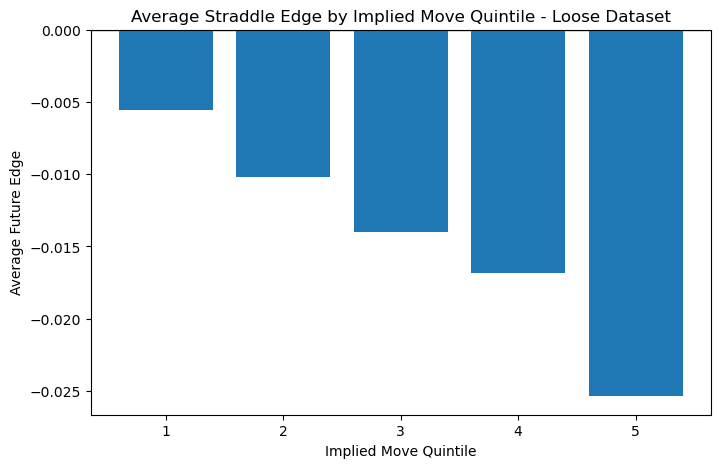

In [16]:
# Plot average edge by implied move quintile.
#
# This is one of the most important plots.
#
# If the bars become more negative from Q1 to Q5,
# it means higher implied move straddles are more expensive on average.

plot_df = all_quintiles[
    (all_quintiles["dataset"] == "loose") &
    (all_quintiles["signal"] == "implied_move_simple")
].copy()

plt.figure(figsize=(8, 5))
plt.bar(plot_df["quintile"], plot_df["avg_edge"])
plt.axhline(0, linewidth=1)
plt.xlabel("Implied Move Quintile")
plt.ylabel("Average Future Edge")
plt.title("Average Straddle Edge by Implied Move Quintile - Loose Dataset")
plt.show()

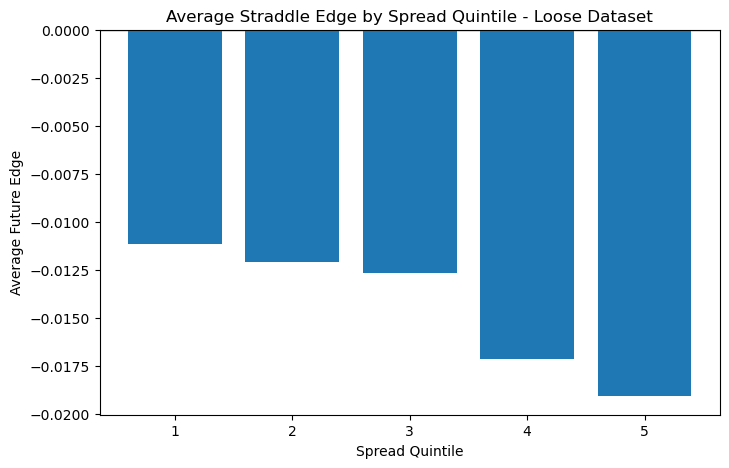

In [17]:
# Plot average edge by spread quintile.
#
# Q1 = tight spreads
# Q5 = wide spreads
#
# This helps us see whether less liquid options have different future edge.

plot_df = all_quintiles[
    (all_quintiles["dataset"] == "loose") &
    (all_quintiles["signal"] == "total_spread_pct")
].copy()

plt.figure(figsize=(8, 5))
plt.bar(plot_df["quintile"], plot_df["avg_edge"])
plt.axhline(0, linewidth=1)
plt.xlabel("Spread Quintile")
plt.ylabel("Average Future Edge")
plt.title("Average Straddle Edge by Spread Quintile - Loose Dataset")
plt.show()

In [18]:
# Now test if the implied move pattern is stable by year.
#
# This is important because a signal is more believable if it works across years,
# not just because of one strange year.
#
# We use loose_work first.

con.execute("""
CREATE OR REPLACE TEMP TABLE implied_quintile_by_year_loose AS
WITH ranked AS (
    SELECT
        *,
        NTILE(5) OVER (
            PARTITION BY earnings_year
            ORDER BY implied_move_simple
        ) AS quintile
    FROM loose_work
    WHERE implied_move_simple IS NOT NULL
      AND simple_straddle_edge_open IS NOT NULL
)

SELECT
    'loose' AS dataset,
    earnings_year,
    quintile,
    COUNT(*) AS n_events,
    AVG(implied_move_simple) AS avg_implied_move,
    AVG(realized_move_open_to_prevclose) AS avg_realized_move,
    AVG(simple_straddle_edge_open) AS avg_edge,
    AVG(CASE WHEN simple_straddle_edge_open > 0 THEN 1 ELSE 0 END) AS pct_positive_edge
FROM ranked
GROUP BY earnings_year, quintile
ORDER BY earnings_year, quintile
""")

show(
    "Year-by-year implied move quintile results: loose",
    """
    SELECT *
    FROM implied_quintile_by_year_loose
    ORDER BY earnings_year, quintile
    """,
    n=100
)


Year-by-year implied move quintile results: loose
dataset  earnings_year  quintile  n_events  avg_implied_move  avg_realized_move  avg_edge  pct_positive_edge
  loose           2018         1       194          0.030392           0.024260 -0.006132           0.283505
  loose           2018         2       194          0.039798           0.033410 -0.006388           0.355670
  loose           2018         3       193          0.048869           0.038452 -0.010417           0.290155
  loose           2018         4       193          0.059689           0.047405 -0.012284           0.331606
  loose           2018         5       193          0.085768           0.064759 -0.021009           0.248705
  loose           2019         1       265          0.030090           0.021461 -0.008629           0.252830
  loose           2019         2       265          0.039021           0.028199 -0.010822           0.245283
  loose           2019         3       264          0.048171           0.0362

,dataset,earnings_year,quintile,n_events,avg_implied_move,avg_realized_move,avg_edge,pct_positive_edge
0,loose,2018,1,194,0.030392,0.024260,-0.006132,0.283505
1,loose,2018,2,194,0.039798,0.033410,-0.006388,0.355670
2,loose,2018,3,193,0.048869,0.038452,-0.010417,0.290155
3,loose,2018,4,193,0.059689,0.047405,-0.012284,0.331606
4,loose,2018,5,193,0.085768,0.064759,-0.021009,0.248705
5,loose,2019,1,265,0.030090,0.021461,-0.008629,0.252830
6,loose,2019,2,265,0.039021,0.028199,-0.010822,0.245283
7,loose,2019,3,264,0.048171,0.036266,-0.011905,0.291667
8,loose,2019,4,264,0.058954,0.043965,-0.014989,0.295455
9,loose,2019,5,264,0.084746,0.062244,-0.022502,0.257576


In [19]:
# For each year, compare Q5 vs Q1.
#
# This tells us whether the high implied-move group differs from the low implied-move group each year.

yearly_spread = con.execute("""
SELECT
    earnings_year,
    MAX(CASE WHEN quintile = 1 THEN avg_edge END) AS q1_edge,
    MAX(CASE WHEN quintile = 5 THEN avg_edge END) AS q5_edge,
    MAX(CASE WHEN quintile = 5 THEN avg_edge END)
        - MAX(CASE WHEN quintile = 1 THEN avg_edge END) AS q5_minus_q1_edge
FROM implied_quintile_by_year_loose
GROUP BY earnings_year
ORDER BY earnings_year
""").df()

display(yearly_spread)

,earnings_year,q1_edge,q5_edge,q5_minus_q1_edge
0,2018,-0.006132,-0.021009,-0.014877
1,2019,-0.008629,-0.022502,-0.013873
2,2020,-0.005498,-0.041128,-0.035630
3,2021,-0.005715,-0.023930,-0.018215
4,2022,-0.005864,-0.034369,-0.028505
5,2023,-0.003359,-0.014501,-0.011142
6,2024,-0.004924,-0.016934,-0.012011


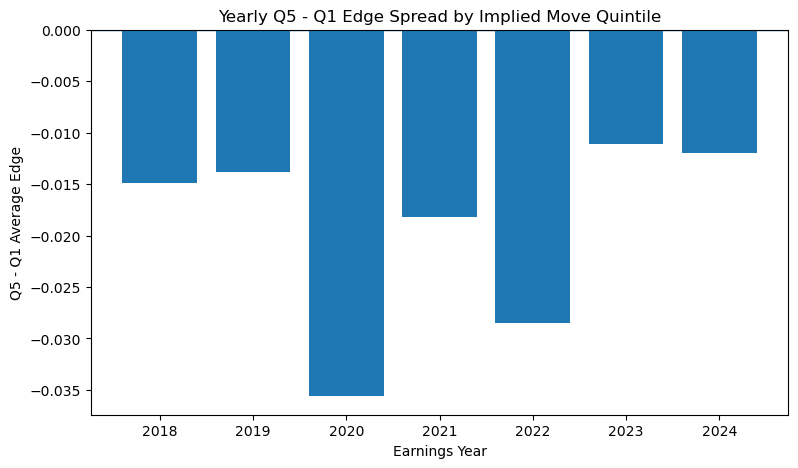

In [20]:
# Plot yearly Q5 - Q1 edge spread for implied move.
#
# If this is usually negative:
#     high implied-move straddles have worse edge than low implied-move straddles.

plt.figure(figsize=(9, 5))
plt.bar(yearly_spread["earnings_year"], yearly_spread["q5_minus_q1_edge"])
plt.axhline(0, linewidth=1)
plt.xlabel("Earnings Year")
plt.ylabel("Q5 - Q1 Average Edge")
plt.title("Yearly Q5 - Q1 Edge Spread by Implied Move Quintile")
plt.show()

In [21]:
# Check edge by earnings month.
#
# This tells us whether some earnings months have more expensive/cheap straddles.
#
# This is not the main signal yet, but it is useful context.

show(
    "Average edge by earnings month: loose",
    """
    SELECT
        earnings_month,
        COUNT(*) AS n_events,
        AVG(implied_move_simple) AS avg_implied_move,
        AVG(realized_move_open_to_prevclose) AS avg_realized_move,
        AVG(simple_straddle_edge_open) AS avg_edge,
        AVG(CASE WHEN simple_straddle_edge_open > 0 THEN 1 ELSE 0 END) AS pct_positive_edge
    FROM loose_work
    GROUP BY earnings_month
    ORDER BY earnings_month
    """
)


Average edge by earnings month: loose
 earnings_month  n_events  avg_implied_move  avg_realized_move  avg_edge  pct_positive_edge
              1       647          0.050000           0.038864 -0.011137           0.319938
              2      1291          0.057538           0.041452 -0.016085           0.259489
              3       175          0.071215           0.052020 -0.019195           0.268571
              4       963          0.050979           0.038010 -0.012969           0.298027
              5      1178          0.063270           0.043362 -0.019908           0.235993
              6       133          0.065382           0.051563 -0.013819           0.308271
              7      1073          0.047980           0.037993 -0.009987           0.304753
              8      1079          0.061820           0.044568 -0.017252           0.253012
              9       118          0.062641           0.054199 -0.008443           0.338983
             10      1169          0.0521

,earnings_month,n_events,avg_implied_move,avg_realized_move,avg_edge,pct_positive_edge
0,1,647,0.050000,0.038864,-0.011137,0.319938
1,2,1291,0.057538,0.041452,-0.016085,0.259489
2,3,175,0.071215,0.052020,-0.019195,0.268571
3,4,963,0.050979,0.038010,-0.012969,0.298027
4,5,1178,0.063270,0.043362,-0.019908,0.235993
5,6,133,0.065382,0.051563,-0.013819,0.308271
6,7,1073,0.047980,0.037993,-0.009987,0.304753
7,8,1079,0.061820,0.044568,-0.017252,0.253012
8,9,118,0.062641,0.054199,-0.008443,0.338983
9,10,1169,0.052167,0.039906,-0.012261,0.293413


In [22]:
# Check simple correlations with future edge.
#
# Correlation tells us whether two variables move together.
#
# Positive correlation:
#     when signal is higher, edge tends to be higher
#
# Negative correlation:
#     when signal is higher, edge tends to be lower
#
# This is only a rough check, not final proof.

show(
    "Correlation with future edge: loose",
    """
    SELECT
        CORR(implied_move_simple, simple_straddle_edge_open) AS corr_implied_move_edge,
        CORR(total_spread_pct, simple_straddle_edge_open) AS corr_spread_edge,
        CORR(log_total_open_interest, simple_straddle_edge_open) AS corr_open_interest_edge,
        CORR(log_total_volume, simple_straddle_edge_open) AS corr_volume_edge,
        CORR(om_close, simple_straddle_edge_open) AS corr_stock_price_edge
    FROM loose_work
    """
)


Correlation with future edge: loose
 corr_implied_move_edge  corr_spread_edge  corr_open_interest_edge  corr_volume_edge  corr_stock_price_edge
              -0.239097         -0.072864                    0.001          0.090099               0.023513


,corr_implied_move_edge,corr_spread_edge,corr_open_interest_edge,corr_volume_edge,corr_stock_price_edge
0,-0.239097,-0.072864,0.001,0.090099,0.023513


In [23]:
# Save the combined quintile results to parquet.
#
# This is useful later when writing the report or building charts.

if os.path.exists(quintile_results_file):
    os.remove(quintile_results_file)

con.register("all_quintiles_df", all_quintiles)

con.execute(f"""
COPY all_quintiles_df
TO '{quintile_results_file}'
(FORMAT PARQUET)
""")

print("Saved quintile results to:")
print(quintile_results_file)

Saved quintile results to:
data\processed\modeling_part2_quintile_results.parquet


In [24]:
# Save yearly implied-move quintile results.

if os.path.exists(yearly_quintile_results_file):
    os.remove(yearly_quintile_results_file)

con.execute(f"""
COPY implied_quintile_by_year_loose
TO '{yearly_quintile_results_file}'
(FORMAT PARQUET)
""")

print("Saved yearly quintile results to:")
print(yearly_quintile_results_file)

Saved yearly quintile results to:
data\processed\modeling_part2_yearly_quintile_results.parquet


In [25]:
# Final summary table for the notebook.
#
# Look at this table first after running the notebook.

display(long_short_summary)

print("""
How to read this:

q1_edge:
    Average future edge for lowest signal quintile.

q5_edge:
    Average future edge for highest signal quintile.

q5_minus_q1_edge:
    Difference between highest and lowest signal quintiles.

For implied_move_simple:
    If q5_minus_q1_edge is negative,
    high implied move straddles were more expensive than low implied move straddles.

For future modeling:
    We want signals that create clear separation in future edge.
""")

quintile,dataset,signal,q1_edge,q5_edge,q5_minus_q1_edge
0,loose,implied_move_simple,-0.005567,-0.025384,-0.019817
4,loose,total_spread_pct,-0.011134,-0.019076,-0.007942
1,loose,log_total_open_interest,-0.014147,-0.015383,-0.001236
3,loose,om_close,-0.017863,-0.012090,0.005773
2,loose,log_total_volume,-0.020498,-0.010727,0.009770
5,strict,implied_move_simple,-0.005031,-0.024635,-0.019604
9,strict,total_spread_pct,-0.010436,-0.018283,-0.007847
6,strict,log_total_open_interest,-0.013143,-0.014563,-0.001420
8,strict,om_close,-0.017673,-0.011379,0.006294
7,strict,log_total_volume,-0.019130,-0.010834,0.008295



How to read this:

q1_edge:
    Average future edge for lowest signal quintile.

q5_edge:
    Average future edge for highest signal quintile.

q5_minus_q1_edge:
    Difference between highest and lowest signal quintiles.

For implied_move_simple:
    If q5_minus_q1_edge is negative,
    high implied move straddles were more expensive than low implied move straddles.

For future modeling:
    We want signals that create clear separation in future edge.

